In [15]:
import pandas as pd
import joblib

# 1. Data ටික Load කරගැනීම
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

# y values එක තීරුවක් නිසා ඒක pandas Series එකක් විදිහට ගන්න .squeeze() පාවිච්චි කරනවා
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# 2. Preprocessor එක Load කරගැනීම
preprocessor = joblib.load('../models/preprocessor.pkl')

print("Data සහ Preprocessor සාර්ථකව Load කරගත්තා!")

Data සහ Preprocessor සාර්ථකව Load කරගත්තා!


In [16]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.pipeline import Pipeline

In [17]:
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb_model', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

In [18]:
# මතකද අර රහස? Pipeline එකේ නම 'xgb_model' නිසා, හැම parameter එකකටම කලින් 'xgb_model__' එන්න ඕන.
param_grid = {
    'xgb_model__n_estimators': [100, 200, 300],          # ගස් ගණන
    'xgb_model__learning_rate': [0.01, 0.05, 0.1, 0.2],  # ඉගෙනගන්න වේගය
    'xgb_model__max_depth': [3, 4, 5, 6],                # ගහක ගැඹුර
    'xgb_model__subsample': [0.6, 0.8, 1.0],             # පේළි වලින් ගන්න ප්‍රතිශතය
    'xgb_model__colsample_bytree': [0.6, 0.8, 1.0]       # තීරු වලින් ගන්න ප්‍රතිශතය
}


In [19]:
random_search = RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_grid,
    n_iter=20,  # හොඳම 20 combinations පමණක් පරීක්ෂා කරන්න
    cv=3,       # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1   # හැම CPU core එකක්ම භාවිතා කරන්න
)
# 4. ගේම පටන් ගමු! (Train කිරීම)
print("AI Model එක Train වෙමින් පවතී... (මෙයට සුළු වේලාවක් ගතවිය හැක)....")
random_search.fit(X_train, y_train)

# 5. ප්‍රතිඵල බැලීම
print("\n--- Training අවසන්! ---")
print("හොඳම Parameters ටික:", random_search.best_params_)

# RMSE එක ගණනය කිරීම (අර negative අගය ධන කරලා වර්ගමූලය ගන්න ඕන)
best_rmse = np.sqrt(np.abs(random_search.best_score_))
print(f"හොඳම RMSE (මිලෙහි සාමාන්‍ය දෝෂය): ₹ {best_rmse:,.2f}")

AI Model එක Train වෙමින් පවතී... (මෙයට සුළු වේලාවක් ගතවිය හැක)....
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Training අවසන්! ---
හොඳම Parameters ටික: {'xgb_model__subsample': 1.0, 'xgb_model__n_estimators': 200, 'xgb_model__max_depth': 6, 'xgb_model__learning_rate': 0.1, 'xgb_model__colsample_bytree': 1.0}
හොඳම RMSE (මිලෙහි සාමාන්‍ය දෝෂය): ₹ 0.84


Test Data සඳහා අවසාන RMSE: ලක්ෂ 842306.24 යි.
AI එන්ජිමේ නිරවද්‍යතාවය (R-Squared Score): 75.69%


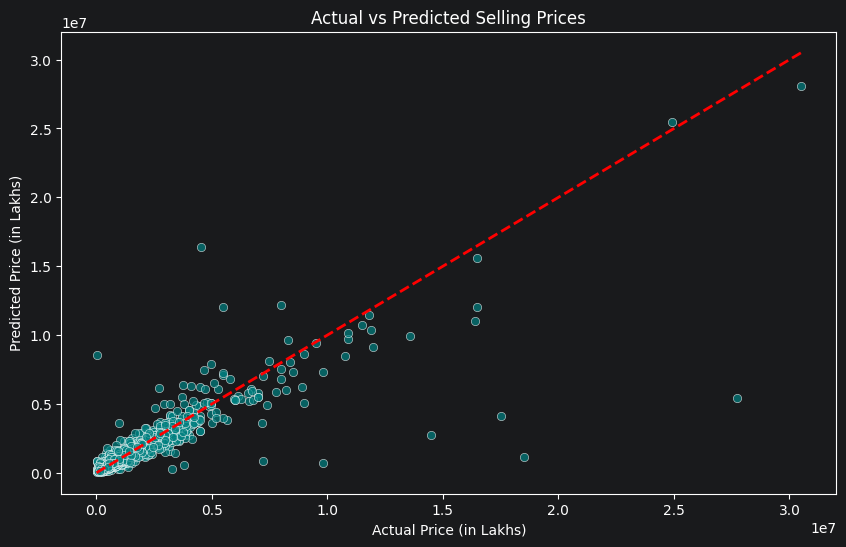

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. අර හොයාගත්ත හොඳම Model එක තෝරාගැනීම
best_model = random_search.best_estimator_

# 2. අපි කලින් වෙන් කරපු Test දත්ත (X_test) සඳහා මිල අනුමාන කිරීම
y_pred = best_model.predict(X_test)

# 3. අවසාන දෝෂය (RMSE) සහ R2 Score (නිරවද්‍යතාවය) ගණනය කිරීම
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test Data සඳහා අවසාන RMSE: ලක්ෂ {final_rmse:.2f} යි.")
print(f"AI එන්ජිමේ නිරවද්‍යතාවය (R-Squared Score): {r2 * 100:.2f}%")

# 4. ඇත්ත මිල සහ AI අනුමාන කළ මිල සන්සන්දනය කරන ප්‍රස්ථාරය
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal')

# 100% නිවැරදි නම් තිත් වැටිය යුතු රේඛාව (Perfect Prediction Line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)

plt.xlabel('Actual Price (in Lakhs)')
plt.ylabel('Predicted Price (in Lakhs)')
plt.title('Actual vs Predicted Selling Prices')
plt.show()